# **Sentiment Analysis of Product Reviews**
The goal of this project is to analyse customer reviews to determine their sentiment (positive, negative or neutral) based on the text content of the reviews and associated metadata. This will help in understanding customer feedback, identifying product strengths and weaknesses and improving the overall customer experience by offering actionable insights.

---

### **Problem Statement**
E-commerce platforms like Amazon, Jumia, Konga, Ebay, Ali Express and other online retailers in Nigeria and beyond collect millions of product reviews daily. These reviews are rich sources of customer feedback but are often unstructured, making manual analysis time-consuming and inefficient. Companies often need to quickly interpret the sentiments expressed in these reviews to understand how customers feel about their products, identify key pain points and adjust their business strategies accordingly. However, sorting through vast amounts of text data to understand customer sentiment (positive, neutral, or negative) poses a significant challenge. This project aims to automate the process of sentiment analysis using machine learning (ML) and natural language processing (NLP) techniques. By automating sentiment detection, businesses can gain real-time insights from reviews, leading to better decision-making, improved product offerings and enhanced customer satisfaction.

---

### **Key Steps in the Project**

1. **Data Collection**: Utilise the provided dataset containing customer reviews and associated metadata, such as star ratings and product categories.
2. **Data Preprocessing**: Handle missing data, clean text (e.g remove noise and irrelevant symbols) and standardise review content.
3. **Sentiment Labelling**: Use star ratings to label reviews as negative (1-2 stars), neutral (3 stars) or positive (4-5 stars).
4. **Exploratory Data Analysis (EDA)**:  Visualise the distribution of sentiments across different product categories and review ratings.
5. **Feature Extraction and Text Processing**: Convert review text into numerical features using tokenization, stopword removal and TF-IDF vectorization.
6. **Model Selection and Model Training**: Train a machine learning model (such as logistic regression, random forest or neural networks) to predict review sentiment based on extracted features.
7. **Model Evaluation**: Assess model performance using accuracy, precision, recall and F1 score to ensure reliable sentiment predictions.
8. **Performance Metrics**: Analyse metrics like confusion matrix and detailed performance scores to understand the strengths and weaknesses of the model.
9. **Building a Sentiment Analysis Dashboard with Streamlit and Real-Time Sentiment Prediction**: Create an interactive dashboard to visualise sentiment distribution and allow users to input reviews for real-time sentiment predictions.
10. **Business Insights and Recommendations**: Provide actionable insights and recommendations to businesses to improve product offerings based on patterns identified in customer feedback.

## **Importing Necessary Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import nltk 
import re
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer , ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix , accuracy_score , f1_score , precision_score , recall_score


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rniti\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rniti\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:

import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import ExtraTreesClassifier

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

## **

In [88]:
# Load the dataset with the correct delimiter
file_path = r"E:\Product-Review-Sentiment-Analysis-main\Product-Review-Sentiment-Analysis-main\Amazon Product Review.txt"
data = pd.read_csv(file_path, delimiter=",", encoding="utf-8")

# Check the columns in the dataset
print("Columns in the dataset:")
print(data.columns)

Columns in the dataset:
Index(['marketplace', 'customer_id', 'review_id', 'product_id',
       'product_parent', 'product_title', 'product_category', 'star_rating',
       'helpful_votes', 'total_votes', 'vine', 'verified_purchase',
       'review_headline', 'review_body', 'review_date', 'sentiment'],
      dtype='object')


In [89]:

# Display the first few rows of the dataset to verify its structure
print(data.head())

  marketplace  customer_id       review_id  product_id  product_parent  \
0          US     11555559  R1QXC7AHHJBQ3O  B00IKPX4GY         2693241   
1          US     31469372  R175VSRV6ZETOP  B00IKPYKWG         2693241   
2          US     26843895  R2HRFF78MWGY19  B00IKPW0UA         2693241   
3          US     19844868   R8Q39WPKYVSTX  B00LCHSHMS         2693241   
4          US      1189852  R3RL4C8YP2ZCJL  B00IKPZ5V6         2693241   

                           product_title product_category  star_rating  \
0  Fire HD 7, 7" HD Display, Wi-Fi, 8 GB               PC            5   
1  Fire HD 7, 7" HD Display, Wi-Fi, 8 GB               PC            3   
2  Fire HD 7, 7" HD Display, Wi-Fi, 8 GB               PC            5   
3  Fire HD 7, 7" HD Display, Wi-Fi, 8 GB               PC            4   
4  Fire HD 7, 7" HD Display, Wi-Fi, 8 GB               PC            5   

   helpful_votes  total_votes vine verified_purchase  \
0              0            0    N                 Y  

In [90]:
data.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,sentiment
0,US,11555559,R1QXC7AHHJBQ3O,B00IKPX4GY,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,Great love it,2015-08-31,1
1,US,31469372,R175VSRV6ZETOP,B00IKPYKWG,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,3,0,0,N,N,Lots of ads Slow processing speed Occasionally...,Lots of ads<br />Slow processing speed<br />Oc...,2015-08-31,0
2,US,26843895,R2HRFF78MWGY19,B00IKPW0UA,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Well thought out device,Excellent unit. The versatility of this table...,2015-08-31,1
3,US,19844868,R8Q39WPKYVSTX,B00LCHSHMS,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,4,0,0,N,N,Not all apps/games we were looking forward to ...,I bought this on Amazon Prime so I ended up bu...,2015-08-31,1
4,US,1189852,R3RL4C8YP2ZCJL,B00IKPZ5V6,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,All Amazon products continue to meet my expect...,2015-08-31,1


In [91]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30846 entries, 0 to 30845
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   marketplace        30846 non-null  object
 1   customer_id        30846 non-null  int64 
 2   review_id          30846 non-null  object
 3   product_id         30846 non-null  object
 4   product_parent     30846 non-null  int64 
 5   product_title      30846 non-null  object
 6   product_category   30846 non-null  object
 7   star_rating        30846 non-null  int64 
 8   helpful_votes      30846 non-null  int64 
 9   total_votes        30846 non-null  int64 
 10  vine               30846 non-null  object
 11  verified_purchase  30846 non-null  object
 12  review_headline    30844 non-null  object
 13  review_body        30842 non-null  object
 14  review_date        30846 non-null  object
 15  sentiment          30846 non-null  int64 
dtypes: int64(6), object(10)
memory usage: 3.

## Data Preprocessing Or Text Preprocessing

In [92]:
# Rename columns
data.columns = data.columns.str.strip()  # Remove leading/trailing whitespace from column names

In [93]:
# Checking for missing values
data.isnull().sum()

marketplace          0
customer_id          0
review_id            0
product_id           0
product_parent       0
product_title        0
product_category     0
star_rating          0
helpful_votes        0
total_votes          0
vine                 0
verified_purchase    0
review_headline      2
review_body          4
review_date          0
sentiment            0
dtype: int64

In [94]:
print("Total missing values in the dataset:", data.isnull().sum().sum())

Total missing values in the dataset: 6


In [95]:
# Drop rows with missing values in 'review_headline' and 'review_body' columns
data.dropna(subset=['review_headline', 'review_body'], inplace=True)

In [96]:
class TextCleaner(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.stop_words = set(ENGLISH_STOP_WORDS) - {'not', 'no', 'nor'}
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X.apply(self.clean_text)
    
    def clean_text(self, text):
        text = str(text).lower()                        
        text = re.sub(r'<.*?>', '', text)               # Remove HTML tags
        text = re.sub(r'\d+', '', text)                 # Remove numbers
        text = re.sub(r'[^a-zA-Z\s]', '', text)         # Remove punctuation
        text = re.sub(r'\s+', ' ', text).strip()        # Remove extra whitespace

        # Remove stopwords
        words = text.split()
        words = [w for w in words if w not in self.stop_words]
        
        return " ".join(words)

In [97]:
data[['review_headline', 'review_body']]

,review_headline,review_body
0,Five Stars,Great love it
1,Lots of ads Slow processing speed Occasionally...,Lots of ads<br />Slow processing speed<br />Oc...
2,Well thought out device,Excellent unit. The versatility of this table...
3,Not all apps/games we were looking forward to ...,I bought this on Amazon Prime so I ended up bu...
4,Five Stars,All Amazon products continue to meet my expect...
...,...,...
30841,A great upgrade for me from an older Kindle Fire!,[[VIDEOID:moP3B6GS5RL8LY]]I purchased the orig...
30842,Great Value for $139,I'm writing this review with the benefit of be...
30843,Even grandma has it figured out!,"I purchased this Kindle for my grandma, becaus..."
30844,The Honda Accord of Tablets,I bought my tablet Fire HD 7 at Best Buy on th...


In [98]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30840 entries, 0 to 30845
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   marketplace        30840 non-null  object
 1   customer_id        30840 non-null  int64 
 2   review_id          30840 non-null  object
 3   product_id         30840 non-null  object
 4   product_parent     30840 non-null  int64 
 5   product_title      30840 non-null  object
 6   product_category   30840 non-null  object
 7   star_rating        30840 non-null  int64 
 8   helpful_votes      30840 non-null  int64 
 9   total_votes        30840 non-null  int64 
 10  vine               30840 non-null  object
 11  verified_purchase  30840 non-null  object
 12  review_headline    30840 non-null  object
 13  review_body        30840 non-null  object
 14  review_date        30840 non-null  object
 15  sentiment          30840 non-null  int64 
dtypes: int64(6), object(10)
memory usage: 4.0+ MB

## **Sentiment Labelling** 

In [99]:
# Function to label sentiment based on star ratings
def label_sentiment(star_rating):
    if star_rating in [1, 2]:
        return 'negative'
    elif star_rating == 3:
        return 'neutral'
    elif star_rating in [4, 5]:
        return 'positive'
    else:
        return 'unknown'  # In case of unexpected values

# Apply the function to the 'star_rating' column
data['sentiment_label'] = data['star_rating'].apply(label_sentiment)

# Verify the new column
print("Sentiment labels based on star ratings:")
print(data[['star_rating', 'sentiment_label']].head())

Sentiment labels based on star ratings:
   star_rating sentiment_label
0            5        positive
1            3         neutral
2            5        positive
3            4        positive
4            5        positive


In [100]:
data.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,sentiment,sentiment_label
0,US,11555559,R1QXC7AHHJBQ3O,B00IKPX4GY,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,Great love it,2015-08-31,1,positive
1,US,31469372,R175VSRV6ZETOP,B00IKPYKWG,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,3,0,0,N,N,Lots of ads Slow processing speed Occasionally...,Lots of ads<br />Slow processing speed<br />Oc...,2015-08-31,0,neutral
2,US,26843895,R2HRFF78MWGY19,B00IKPW0UA,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Well thought out device,Excellent unit. The versatility of this table...,2015-08-31,1,positive
3,US,19844868,R8Q39WPKYVSTX,B00LCHSHMS,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,4,0,0,N,N,Not all apps/games we were looking forward to ...,I bought this on Amazon Prime so I ended up bu...,2015-08-31,1,positive
4,US,1189852,R3RL4C8YP2ZCJL,B00IKPZ5V6,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,All Amazon products continue to meet my expect...,2015-08-31,1,positive


In [101]:
data['sentiment_label'].value_counts()

sentiment_label
positive    25763
negative     2861
neutral      2216
Name: count, dtype: int64

## **Exploratory Data Analysis**

### **1. Traget Distribution**

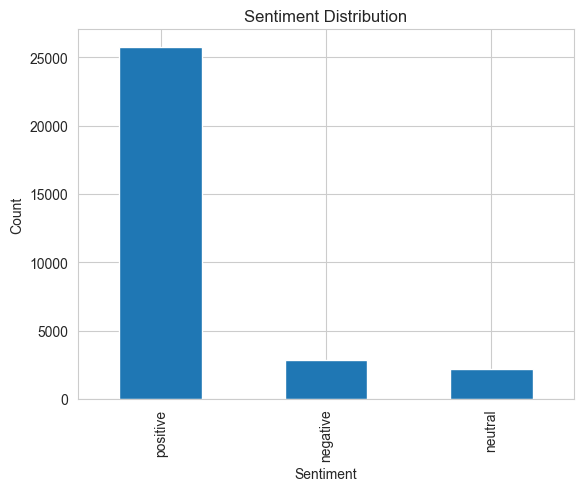

In [102]:

data['sentiment_label'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


### **Interpretation of Traget Distribution**

The dataset shows a **strong imbalance,** with positive sentiment dominating over negative and neutral sentiments. This can be a concern in machine learning models, as the model may become biased toward predicting positive outcomes. Techniques like **resampling or class weighting** may be required to handle this imbalance.

### **2. Star Rating Distribution**

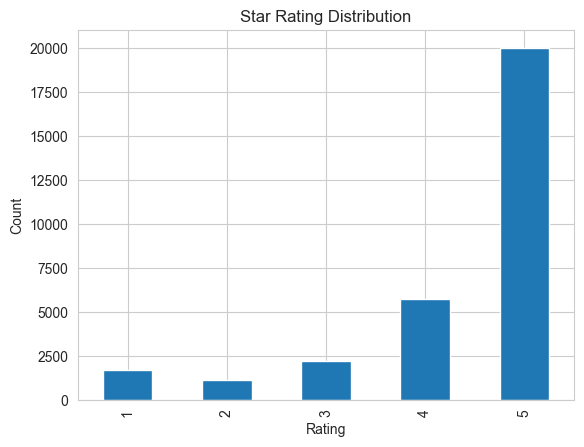

In [103]:
data['star_rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Star Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

### **Interpretation of Star Rating Distribution**

**1. 5-Star Ratings (Highly Dominant):**
The 5-star ratings have the highest count, around **20,000 entries**. This shows that a large majority of users are extremely satisfied. It suggests strong performance, quality, and customer approval, making it a key strength for the business.

**2. 4-Star Ratings (Second Highest):**
4-star ratings are the second most common, with around **5,000–6,000 entries**. These users are generally satisfied but may have minor concerns. This group represents an opportunity to convert satisfied users into highly satisfied ones.

**3. 3-Star Ratings (Moderate Feedback):**
3-star ratings are moderate, around **2,000 entries**. These users have an average experience, indicating neither strong satisfaction nor dissatisfaction. Their feedback is important for identifying areas that need improvement.

**4. 2-Star Ratings (Low Dissatisfaction):**
2-star ratings are relatively low, around **1,000 entries**. These users are somewhat dissatisfied, and their feedback may highlight specific issues that are affecting user experience.

**5. 1-Star Ratings (Least but Critical):**
1-star ratings account for about **1,500–2,000 entries**. Although fewer in number, they represent highly dissatisfied users. These reviews are critical as they often point to major problems that need immediate attention.

### **3. Sentiment Distribution Across Star Ratings**

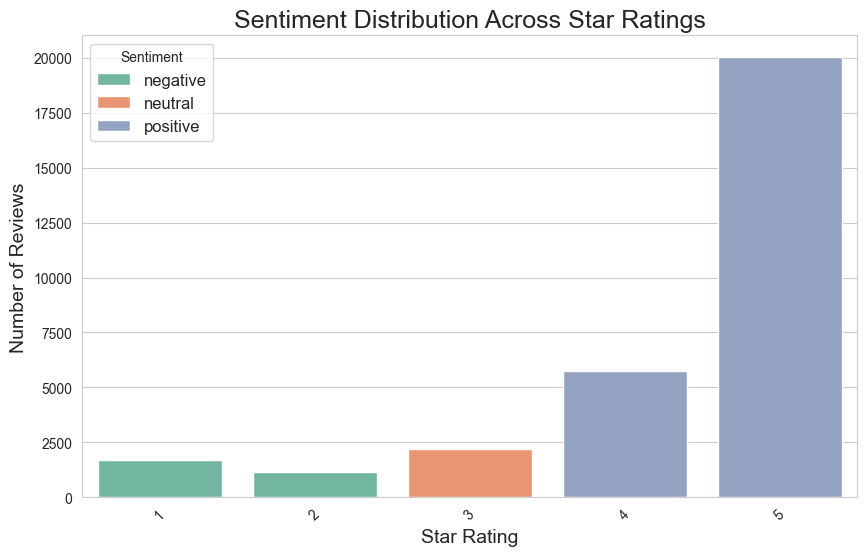

In [104]:
# 1. Sentiment Distribution Across Star Ratings
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='star_rating', hue='sentiment_label', palette='Set2')
plt.title('Sentiment Distribution Across Star Ratings', fontsize=18)
plt.xlabel('Star Rating', fontsize=14)
plt.ylabel('Number of Reviews', fontsize=14)
plt.legend(title='Sentiment', fontsize=12)
plt.xticks(rotation=45)
plt.show()

### **4. Verified Purchase Analysis**

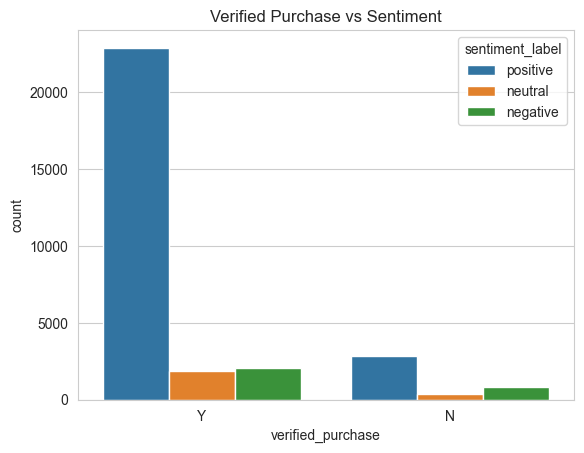

In [105]:

sns.countplot(x='verified_purchase', hue='sentiment_label', data=data)
plt.title("Verified Purchase vs Sentiment")
plt.show()

### **Interpretation of Verified Purchase Analysis**

- **Verified purchases (Y)** contribute the majority of reviews, showing that most feedback comes from genuine buyers.
Positive sentiment dominates heavily among verified buyers, indicating strong customer satisfaction with the product.
Neutral and negative reviews for verified purchases are present but relatively low, suggesting only minor concerns.

- **Non-verified purchases (N)** have very few reviews overall, so they are less reliable for decision-making.
In non-verified reviews, the gap between positive, neutral, and negative is smaller, meaning opinions are more mixed compared to verified buyers.
Verified reviews appear more trustworthy and consistent, making them a better indicator of actual product performance.
Overall, the product has a strong positive perception, especially among real customers.

### **5. Sentiment Distribution Across Product Categories**

<Figure size 1600x800 with 0 Axes>

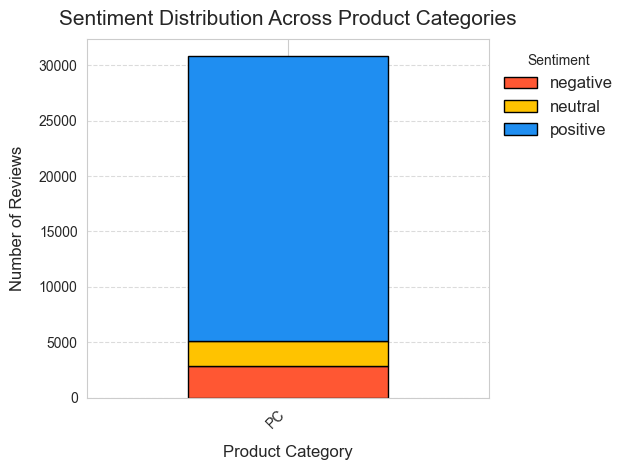

In [106]:
# 2. Sentiment Distribution Across Product Categories

plt.figure(figsize=(16, 8))  # Set figure size for product categories
sentiment_counts_by_category = data.groupby('product_category')['sentiment_label'].value_counts().unstack().fillna(0)

# Plot the distribution of sentiment across product categories
sentiment_counts_by_category.plot(kind='bar', stacked=True, color=['#FF5733', '#FFC300', '#1F8EF1'], edgecolor='black')
plt.title('Sentiment Distribution Across Product Categories', fontsize=15, pad=10)
plt.xlabel('Product Category', fontsize=12, labelpad=10)
plt.ylabel('Number of Reviews', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Sentiment', fontsize=12, bbox_to_anchor=(1, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

### **Interpretation of Sentiment Distribution Across Product Categories**

- **Positive sentiment** dominates heavily, accounting for the vast majority of reviews, indicating strong customer satisfaction with the product.

- **Negative and neutral reviews** are comparatively low, suggesting fewer user complaints or dissatisfaction.

- **Overall sentiment** trend is highly skewed toward positivity, which is favorable for business insights and model learning.

### **6. Word Cloud of Review Text**

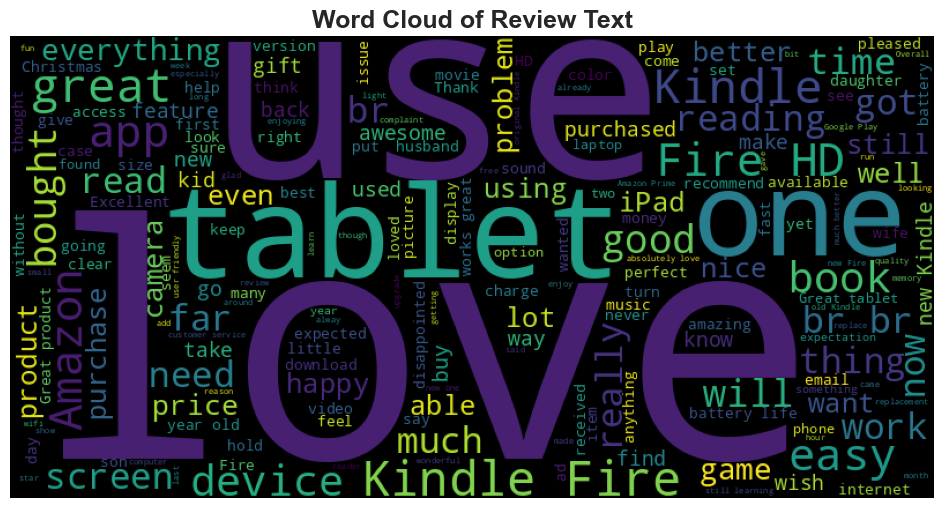

In [107]:

text = " ".join(data['review_body'].astype(str))

wordcloud = WordCloud(width=800, height=400, random_state=42).generate(text)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud of Review Text", fontsize=18 ,fontweight='bold')
plt.show()

### **7. Top Most Frequent Words**

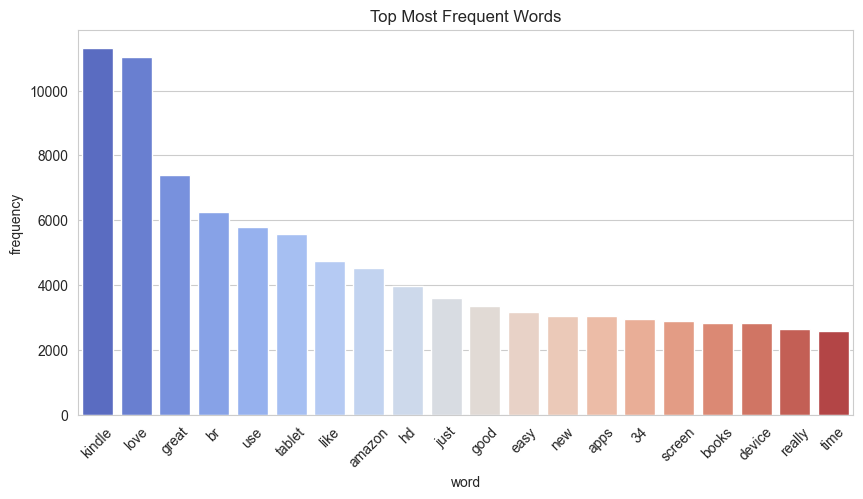

In [ ]:

vectorizer = CountVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(data['review_body'])

words = vectorizer.get_feature_names_out()
counts = X.toarray().sum(axis=0)

# Create a DataFrame of most common words and their frequencies
word_freq = pd.DataFrame({'word': words, 'frequency': counts})
word_freq.sort_values(by='frequency', ascending=False)

import seaborn as sns

# Sort values
word_freq = word_freq.sort_values(by='frequency', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='word', y='frequency', data=word_freq, palette='coolwarm')

plt.xticks(rotation=45)
plt.title("Top Most Frequent Words")
plt.show()


## **Feature Engineering**

In [109]:
# Combine text columns
data['full_review'] = data['review_headline'] + " " + data['review_body']

# Convert categorical
data['verified_purchase'] = data['verified_purchase'].map({'Y':1, 'N':0})


## **TRAIN-TEST SPLIT**

In [110]:

# Features
X = data[['full_review']]

# Target 
y = data['sentiment_label']

### **Column Transformer**

In [111]:
text_pipeline = Pipeline([
    ('cleaner', TextCleaner()),
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2)))
])

preprocessor = ColumnTransformer([
    ('text', text_pipeline, 'full_review')
])

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [113]:
X_train.shape , X_test.shape , y_train.shape , y_test.shape

((24672, 1), (6168, 1), (24672,), (6168,))

# **Model Training**

## **1. Logistic Regression**

In [115]:

lr_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

In [116]:
lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('cleaner',
                                                                   TextCleaner()),
                                                                  ('tfidf',
                                                                   TfidfVectorizer(max_features=5000,
                                                                                   ngram_range=(1,
                                                                                                2)))]),
                                                  'full_review')])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

### **Training set**

In [117]:
# Predict on the Training set
y_train_pred = lr_model.predict(X_train)

In [119]:
# Evaluate on the Training set
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Classification Report:\n", classification_report(y_train, y_train_pred))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

Training Accuracy: 0.8923476005188068
Classification Report:
               precision    recall  f1-score   support

    negative       0.77      0.91      0.83      2295
     neutral       0.46      0.91      0.61      1755
    positive       0.99      0.89      0.94     20622

    accuracy                           0.89     24672
   macro avg       0.74      0.90      0.79     24672
weighted avg       0.93      0.89      0.90     24672

Confusion Matrix:
 [[ 2079   159    57]
 [   94  1592    69]
 [  544  1733 18345]]


### **Test Set**

In [120]:
# Predict on the test set
y_test_pred = lr_model.predict(X_test)

In [121]:
# Evaluate on the Test set

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

Test Accuracy: 0.8312256809338522
Classification Report:
               precision    recall  f1-score   support

    negative       0.59      0.70      0.64       566
     neutral       0.29      0.56      0.38       461
    positive       0.97      0.87      0.92      5141

    accuracy                           0.83      6168
   macro avg       0.62      0.71      0.65      6168
weighted avg       0.89      0.83      0.85      6168

Confusion Matrix:
 [[ 399  145   22]
 [ 108  260   93]
 [ 175  498 4468]]


--------

## **2. Naive Bayes Using MultinomialNB**

In [123]:

nb_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', MultinomialNB())
])

In [124]:
nb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('cleaner',
                                                                   TextCleaner()),
                                                                  ('tfidf',
                                                                   TfidfVectorizer(max_features=5000,
                                                                                   ngram_range=(1,
                                                                                                2)))]),
                                                  'full_review')])),
                ('model', MultinomialNB())])

### **Training Set**

In [125]:
# Predictions of Training set
y_train_pred = nb_model.predict(X_train)

In [126]:
# Evaluate on the Training set

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Classification Report:\n", classification_report(y_train, y_train_pred))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

Training Accuracy: 0.8986705577172504
Classification Report:
               precision    recall  f1-score   support

    negative       0.75      0.70      0.72      2295
     neutral       0.66      0.17      0.27      1755
    positive       0.92      0.98      0.95     20622

    accuracy                           0.90     24672
   macro avg       0.77      0.62      0.65     24672
weighted avg       0.88      0.90      0.88     24672

Confusion Matrix:
 [[ 1601    43   651]
 [  303   293  1159]
 [  233   111 20278]]


### **Test Set**

In [127]:
# Predictions on the test set
y_test_pred = nb_model.predict(X_test)

In [128]:
# Evaluate on the Test set
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

Test Accuracy: 0.881485084306096
Classification Report:
               precision    recall  f1-score   support

    negative       0.70      0.62      0.66       566
     neutral       0.47      0.09      0.15       461
    positive       0.90      0.98      0.94      5141

    accuracy                           0.88      6168
   macro avg       0.69      0.56      0.58      6168
weighted avg       0.85      0.88      0.86      6168

Confusion Matrix:
 [[ 352   18  196]
 [  86   41  334]
 [  68   29 5044]]


--------

## **3. Support Vector Machine**

In [130]:

svm_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearSVC(max_iter=1000, random_state=42, class_weight='balanced'))
])

In [131]:
svm_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('cleaner',
                                                                   TextCleaner()),
                                                                  ('tfidf',
                                                                   TfidfVectorizer(max_features=5000,
                                                                                   ngram_range=(1,
                                                                                                2)))]),
                                                  'full_review')])),
                ('model', LinearSVC(class_weight='balanced', random_state=42))])

### **Training Set**

In [132]:
# Prediction on the Training set
y_train_pred = svm_model.predict(X_train)

In [133]:
# Evaluate on the Training set

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Classification Report:\n", classification_report(y_train, y_train_pred))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

Training Accuracy: 0.9544017509727627
Classification Report:
               precision    recall  f1-score   support

    negative       0.88      0.93      0.90      2295
     neutral       0.70      0.87      0.78      1755
    positive       0.99      0.96      0.98     20622

    accuracy                           0.95     24672
   macro avg       0.86      0.92      0.89     24672
weighted avg       0.96      0.95      0.96     24672

Confusion Matrix:
 [[ 2135   108    52]
 [   94  1534   127]
 [  200   544 19878]]


### **Test Set**

In [134]:
# Prediction on the Test set
y_test_pred = svm_model.predict(X_test)

In [135]:
# Evaluate on the Test set
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))   
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

Test Accuracy: 0.86689364461738
Classification Report:
               precision    recall  f1-score   support

    negative       0.61      0.65      0.63       566
     neutral       0.34      0.40      0.37       461
    positive       0.95      0.93      0.94      5141

    accuracy                           0.87      6168
   macro avg       0.64      0.66      0.65      6168
weighted avg       0.88      0.87      0.87      6168

Confusion Matrix:
 [[ 369  129   68]
 [ 113  183  165]
 [ 121  225 4795]]


---------

## **4. Extra Tress Classifier**

In [137]:
etc_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', ExtraTreesClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

In [138]:
etc_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('cleaner',
                                                                   TextCleaner()),
                                                                  ('tfidf',
                                                                   TfidfVectorizer(max_features=5000,
                                                                                   ngram_range=(1,
                                                                                                2)))]),
                                                  'full_review')])),
                ('model',
                 ExtraTreesClassifier(class_weight='balanced',
                                      random_state=42))])

### **Training Set**

In [139]:
# Prediction on the Training set
y_train_pred = etc_model.predict(X_train)

In [140]:
# Evaluate on the Training set
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Classification Report:\n", classification_report(y_train, y_train_pred))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

Training Accuracy: 0.9962710765239948
Classification Report:
               precision    recall  f1-score   support

    negative       1.00      1.00      1.00      2295
     neutral       0.96      0.99      0.98      1755
    positive       1.00      1.00      1.00     20622

    accuracy                           1.00     24672
   macro avg       0.99      1.00      0.99     24672
weighted avg       1.00      1.00      1.00     24672

Confusion Matrix:
 [[ 2284     5     6]
 [    0  1745    10]
 [    2    69 20551]]


### **Test Set**

In [141]:
# Prediction on the Test set
y_test_pred = etc_model.predict(X_test)

In [142]:
# Evaluate on the Test set
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

Test Accuracy: 0.8728923476005188
Classification Report:
               precision    recall  f1-score   support

    negative       0.75      0.48      0.59       566
     neutral       0.49      0.09      0.15       461
    positive       0.89      0.99      0.93      5141

    accuracy                           0.87      6168
   macro avg       0.71      0.52      0.56      6168
weighted avg       0.84      0.87      0.84      6168

Confusion Matrix:
 [[ 274   10  282]
 [  50   40  371]
 [  39   32 5070]]


------------

## **5. LightGBM**

In [144]:
lgbm_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LGBMClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

In [145]:
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.069436 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 104056
[LightGBM] [Info] Number of data points in the train set: 24672, number of used features: 3099
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('cleaner',
                                                                   TextCleaner()),
                                                                  ('tfidf',
                                                                   TfidfVectorizer(max_features=5000,
                                                                                   ngram_range=(1,
                                                                                                2)))]),
                                                  'full_review')])),
                ('model',
                 LGBMClassifier(class_weight='balanced', random_state=42))])

### **Training Set**

In [146]:
# Prediction on the Training set
y_train_pred = lgbm_model.predict(X_train)

In [147]:
# Evaluate on the Training set
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Classification Report:\n", classification_report(y_train, y_train_pred))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

Training Accuracy: 0.899359597924773
Classification Report:
               precision    recall  f1-score   support

    negative       0.79      0.92      0.85      2295
     neutral       0.48      0.95      0.64      1755
    positive       0.99      0.89      0.94     20622

    accuracy                           0.90     24672
   macro avg       0.76      0.92      0.81     24672
weighted avg       0.94      0.90      0.91     24672

Confusion Matrix:
 [[ 2119   114    62]
 [   31  1661    63]
 [  517  1696 18409]]


### **Test Set**

In [148]:
# Prediction on the Test set
y_test_pred = lgbm_model.predict(X_test)

In [149]:
# Evaluate on the Test set
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

Test Accuracy: 0.8317120622568094
Classification Report:
               precision    recall  f1-score   support

    negative       0.62      0.72      0.67       566
     neutral       0.29      0.57      0.38       461
    positive       0.97      0.87      0.92      5141

    accuracy                           0.83      6168
   macro avg       0.63      0.72      0.65      6168
weighted avg       0.89      0.83      0.85      6168

Confusion Matrix:
 [[ 408  129   29]
 [  98  264   99]
 [ 154  529 4458]]


--------

## **6. CatBoost Classifier** 

In [151]:
cat_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', CatBoostClassifier(iterations=100, random_state=42, class_weights=[1, 1, 1], verbose=0))
])

In [152]:
cat_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('cleaner',
                                                                   TextCleaner()),
                                                                  ('tfidf',
                                                                   TfidfVectorizer(max_features=5000,
                                                                                   ngram_range=(1,
                                                                                                2)))]),
                                                  'full_review')])),
                ('model',
                 CatBoostClassifier(class_weights=[1, 1, 1], iterations=100, random_state=42, verbose=0))])

### **Training Set**

In [153]:
# Prediction on the Training set
y_train_pred = cat_model.predict(X_train)

In [154]:
# Evaluate on the Training set
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Classification Report:\n", classification_report(y_train, y_train_pred))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

Training Accuracy: 0.8968060959792478
Classification Report:
               precision    recall  f1-score   support

    negative       0.76      0.63      0.69      2295
     neutral       0.63      0.21      0.31      1755
    positive       0.92      0.99      0.95     20622

    accuracy                           0.90     24672
   macro avg       0.77      0.61      0.65     24672
weighted avg       0.88      0.90      0.88     24672

Confusion Matrix:
 [[ 1443   106   746]
 [  263   360  1132]
 [  194   105 20323]]


## **Test Set**

In [155]:
# Prediction on the Test set
y_test_pred = cat_model.predict(X_test)

In [156]:
# Evaluate on the Test set
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))   
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

Test Accuracy: 0.8787289234760052
Classification Report:
               precision    recall  f1-score   support

    negative       0.69      0.56      0.62       566
     neutral       0.44      0.13      0.20       461
    positive       0.90      0.98      0.94      5141

    accuracy                           0.88      6168
   macro avg       0.68      0.56      0.59      6168
weighted avg       0.85      0.88      0.86      6168

Confusion Matrix:
 [[ 318   33  215]
 [  87   58  316]
 [  57   40 5044]]


-------

In [ ]:

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metrics
    results = {
        'Model': model_name,
        
        # Train Metrics
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        # 'Train Precision': precision_score(y_train, y_train_pred, average='weighted'),
        # 'Train Recall': recall_score(y_train, y_train_pred, average='weighted'),
        'Train F1': f1_score(y_train, y_train_pred, average='weighted'),
        
        # Test Metrics
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        # 'Test Precision': precision_score(y_test, y_test_pred, average='weighted'),
        # 'Test Recall': recall_score(y_test, y_test_pred, average='weighted'),
        'Test F1': f1_score(y_test, y_test_pred, average='weighted')
    }
    
    return results

In [158]:
models = {
    "Logistic Regression": lr_model,
    "Naive Bayes": nb_model,
    "SVM": svm_model,
    "Extra Trees": etc_model,
    "LightGBM": lgbm_model,
    "CatBoost": cat_model
}

results = [
    evaluate_model(model, X_train, y_train, X_test, y_test, name)
    for name, model in models.items()
]

df_results = pd.DataFrame(results).sort_values(by='Test F1', ascending=False)

df_results.reset_index(drop=True, inplace=True)
df_results.round(4)

,Model,Train Accuracy,Train F1,Test Accuracy,Test F1
0,SVM,0.9544,0.9563,0.8669,0.8714
1,Naive Bayes,0.8987,0.8798,0.8815,0.8561
2,CatBoost,0.8968,0.8794,0.8787,0.8561
3,LightGBM,0.8994,0.9106,0.8317,0.8536
4,Logistic Regression,0.8923,0.9049,0.8312,0.8531
5,Extra Trees,0.9963,0.9963,0.8729,0.8431


## Hyper-parameter tunning using grid search cv 

In [161]:
models = {

    "Logistic Regression": {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'model__C': [0.1, 1, 10],
            'model__solver': ['liblinear', 'lbfgs'],
            'model__class_weight': ['balanced']
        }
    },


    "Naive Bayes": {
        'model': MultinomialNB(),
        'params': {
            'model__alpha': [0.1, 0.5, 1.0],
            'preprocessing__text__tfidf__max_features': [3000, 5000],
            'preprocessing__text__tfidf__ngram_range': [(1,1), (1,2)]
        }
    },

    "SVM": {
        'model': LinearSVC(max_iter=2000, random_state=42),
        'params': {
            'model__C': [0.1, 1, 10],
            'model__class_weight': ['balanced'],
            'preprocessing__text__tfidf__ngram_range': [(1,1), (1,2)]
        }
    },

    "Extra Trees": {
        'model': ExtraTreesClassifier(random_state=42),
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [None, 10, 20],
            'model__class_weight': ['balanced']
        }
    },

    "LightGBM": {
        'model': LGBMClassifier(random_state=42),
        'params': {
            'model__n_estimators': [100, 200],
            'model__learning_rate': [0.05, 0.1],
            'model__num_leaves': [31, 50],
            'model__class_weight': ['balanced']
        }
    },

    "CatBoost": {
        'model': CatBoostClassifier(verbose=0, random_state=42),
        'params': {
            'model__iterations': [100, 200],
            'model__depth': [4, 6],
            'model__learning_rate': [0.05, 0.1]
        }
    }
}

In [ ]:

best_models = []

for name, config in models.items():
    
    print(f"\n{'='*50}")
    print(f"MODEL: {name}")
    print(f"{'='*50}")
    
    # Pipeline
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', config['model'])
    ])
    
    # GridSearch

    grid = GridSearchCV(
        pipeline,
        config['params'],
        cv=3,
        scoring='f1_weighted',
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    
    print("Best Params:", grid.best_params_)
    print("Best CV Score:", grid.best_score_)
    
    
    #  TRAIN PREDICTION
    
    y_train_pred = best_model.predict(X_train)
    
    print("\n--- TRAIN PERFORMANCE ---")
    print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
    print("Train F1 Score:", f1_score(y_train, y_train_pred, average='weighted'))
    print("Train Precision:", precision_score(y_train, y_train_pred, average='weighted'))
    print("Train Recall:", recall_score(y_train, y_train_pred, average='weighted'))
    print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
    
    
    
    # TEST PREDICTION
    
    y_test_pred = best_model.predict(X_test)
    
    print("\n--- TEST PERFORMANCE ---")
    print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
    print("Test F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))
    print("Test Precision:", precision_score(y_test, y_test_pred, average='weighted'))
    print("Test Recall:", recall_score(y_test, y_test_pred, average='weighted'))
    print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
    
    
    # STORE RESULTS
    
    best_models.append({
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Train F1': f1_score(y_train, y_train_pred, average='weighted'),
        'Train Precision': precision_score(y_train, y_train_pred, average='weighted'),
        'Train Recall': recall_score(y_train, y_train_pred, average='weighted'),

        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Test F1': f1_score(y_test, y_test_pred, average='weighted'),
        'Test Precision': precision_score(y_test, y_test_pred, average='weighted'),
        'Test Recall': recall_score(y_test, y_test_pred, average='weighted')
    })

results_df = pd.DataFrame(best_models)
results_df.sort_values(by='Test Accuracy', ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)
print(results_df)


MODEL: Logistic Regression
Best Params: {'model__C': 1, 'model__class_weight': 'balanced', 'model__solver': 'liblinear'}
Best CV Score: 0.8833013861389939

--- TRAIN PERFORMANCE ---
Train Accuracy: 0.9231922827496758
Train F1 Score: 0.9254315563697146
Train Precision: 0.9284175807502939
Train Recall: 0.9231922827496758

Classification Report:
               precision    recall  f1-score   support

    negative       0.78      0.84      0.81      2295
     neutral       0.58      0.66      0.62      1755
    positive       0.97      0.95      0.96     20622

    accuracy                           0.92     24672
   macro avg       0.78      0.82      0.80     24672
weighted avg       0.93      0.92      0.93     24672

Confusion Matrix:
 [[ 1929   206   160]
 [  230  1165   360]
 [  313   626 19683]]

--- TEST PERFORMANCE ---
Test Accuracy: 0.8808365758754864
Test F1 Score: 0.8828507915742008
Test Precision: 0.8850611249348825
Test Recall: 0.8808365758754864

Classification Report:
    

## **Model Comparison And Model Selection**

### **TEST ACCURACY VS TRAIN ACCURACY COMPARSION**

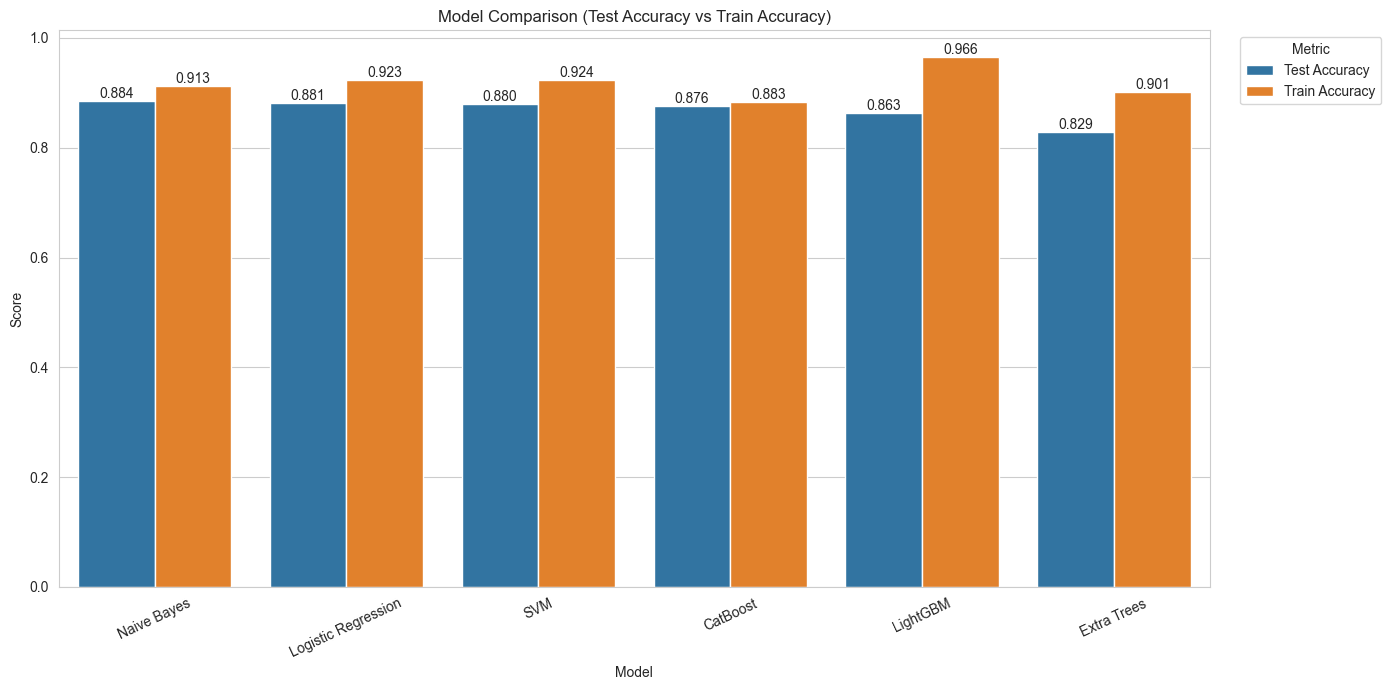

In [ ]:

# Plotting Test Accuracy vs Train Accuracy

plot_df = results_df.melt(
    id_vars="Model",
    value_vars=["Test Accuracy", "Train Accuracy"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=plot_df,
    x="Model",
    y="Score",
    hue="Metric"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),  # outside right
    loc='upper left'
)

plt.title("Model Comparison (Test Accuracy vs Train Accuracy)")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

### **TEST F1 SCORE VS TRAIN F1 SCORE COMPARISON**

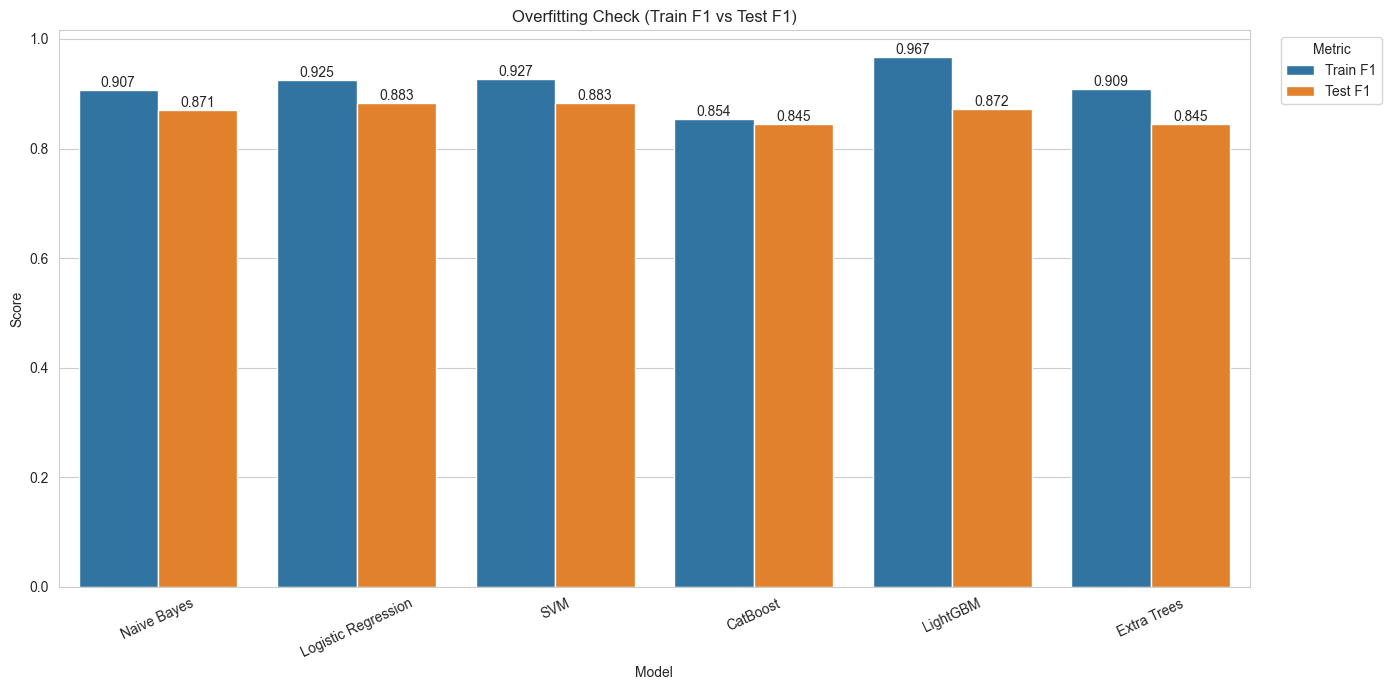

In [ ]:
# Making a copy of results_df to avoid modifying the original DataFrame

plot_df2 = results_df.melt(
    id_vars="Model",
    value_vars=["Train F1", "Test F1"],
    var_name="Metric",
    value_name="Score"
)
 
# Plotting Train F1 vs Test F1

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=plot_df2,
    x="Model",
    y="Score",
    hue="Metric"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Set the title
plt.title("Overfitting Check (Train F1 vs Test F1)")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

## **Final Recommended Model is Logistic Regression**

In [ ]:

# LOGISTIC REGRESSION FINAL CODE

lr_model = LogisticRegression(max_iter=1000, random_state=42)

param_grid = {
    'model__C': [0.1, 1, 10],
    'model__solver': ['liblinear', 'lbfgs'],
    'model__class_weight': ['balanced']
}

# PIPELINE

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', lr_model)
])

# GRID SEARCH

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("\nBest Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

# TRAIN PERFORMANCE

y_train_pred = best_model.predict(X_train)

print("\n--- TRAIN PERFORMANCE ---")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Train F1 Score:", f1_score(y_train, y_train_pred, average='weighted'))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

# TEST PERFORMANCE

y_test_pred = best_model.predict(X_test)

print("\n--- TEST PERFORMANCE ---")
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))


Best Parameters: {'model__C': 1, 'model__class_weight': 'balanced', 'model__solver': 'liblinear'}
Best CV Score: 0.8833013861389939

--- TRAIN PERFORMANCE ---
Train Accuracy: 0.9231922827496758
Train F1 Score: 0.9254315563697146

Classification Report:
               precision    recall  f1-score   support

    negative       0.78      0.84      0.81      2295
     neutral       0.58      0.66      0.62      1755
    positive       0.97      0.95      0.96     20622

    accuracy                           0.92     24672
   macro avg       0.78      0.82      0.80     24672
weighted avg       0.93      0.92      0.93     24672

Confusion Matrix:
 [[ 1929   206   160]
 [  230  1165   360]
 [  313   626 19683]]

--- TEST PERFORMANCE ---
Test Accuracy: 0.8808365758754864
Test F1 Score: 0.8828507915742008

Classification Report:
               precision    recall  f1-score   support

    negative       0.65      0.69      0.67       566
     neutral       0.39      0.41      0.40       461

In [168]:
# Save the cleaned dataset
data.to_csv("cleaned_data.csv", index=False)

In [170]:
# Save the best model
joblib.dump(best_model, "logistic_pipeline.pkl")

['logistic_pipeline.pkl']